<a href="https://colab.research.google.com/github/oooinr4018-web/-1/blob/main/ESAA_0410_%EA%B3%BC%EC%A0%9C%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 앙상블 학습

<앙상블 학습을 통한 분류>

- 여러 개의 분류기 생성 + 예측 결합 -> 보다 정확한 최종 예측 도출

- 앙상블 알고리즘의 대표격: 랜덤 포레스트, 그래디언트 부스팅 알고리즘 (뛰어난 성능, 쉬운 사용, 다양한 활용도)

- XGBoost, LightGBM(XGBoost와 유사한 예측 성능, 훨씬 빠른 수행 속도), 스태킹(여러 모델의 결과 기반 메타 모델 수립)

<앙상블 학습의 유형>

보팅, 배깅: 여러 개의 분류기가 투표를 통해 최종 예측 결과를 결정하는 방식

- 보팅(Voting)

: 서로 다른 알고리즘을 가진 분류기 결합

: 선형 회귀, K 최근접 이웃, 서포트 벡터 머신이라느 3개의 ML 알고리즘이 같은 데이터 세트에 대해 학습, 예측한 결과를 가지고 보팅을 통해 최종 예측 결과 선정하는 방식

- 배깅(bagging)

: 모두 같은 유형의 알고리즘 기반 분류기, 서로 다른 데이터 샘플링 ex) 랜덤 포레스트 알고리즘

:  단일 ML 알고리즘(결정 트리)으로 여러 분류기가 학습으로 개별 예측, 부트스트래핑 분할 방식으로 추출

*부트스트래핑 분할: 개별 분류기에 할당된 학습 데이터는 원본 학습 데이터를 샘플링해 추출

배깅 앙상블 방식: 개별 분류기가 부트스트래핑 방식으로 샘플링된 데이터 세트에 대해 학습을 통해 개별적인 예측을 수행한 결과를 보팅을 통해 최종 예측 결과를 선정하는 방식. 중첩 허용


- 부스팅(Boosting)

: 여러 개의 분류기가 순차적으로 학습 수행

: 앞에서 학습한 분류기가 예측이 틀린 데이터에 대해서는 올바르게 예측할 수 있도록 다음 분류기에게 가중치를 부여하여 학습, 예측 진행

ex)  그래디언트 부스트, XGBoost(Extra Gradient Boost), LightGBM(Light Gradient Boost)


- 스태킹

: 여러 가지 다른 모델의 예측 결괏값을 다시 학습 데이터로 만들어서 다른 모델(메타 모델)로 재학습시켜 결과 예측

# 보팅 유형 - 하드 보팅과 소프트 보팅

- 하드 보팅

예측한 결괏값들 중 다수의 분류기가 결정한 예측값을 최종 보팅 결괏값으로 선정하는 것

- 소프트 보팅

분류기들의 레이블 값 결정 확률을 모두 더하고 이를 평균하여 이들 중 확률이 가장 높은 레이블 값을 최종 보팅 결괏값으로 선정하는 것

*일반적으로 소프트 보팅이 예측 성능이 더 좋고, 보팅 방법으로 적용됨.

# 보팅 분류기

- 사이킷런: 보팅 방식의 앙상블을 구현한 VotingClassifier 클래스 제공 / VotingClassifer 클래스를 이용한 보팅 분류기 생성


- load_breast_cancer() 함수: 위스콘신 유방암 데이터 세트 생성

- 로지스틱 회귀, KNN: 소프트 보팅 방식으로 새롭게 보팅 분류기 생성

- VotingClassifier 클래스 주요 생성 인자: estimators, voting

estimators: 리스트 값으로 보팅에 사용될 여러 개의 Classifier 객체들을 튜플 형식으로 입력받음.

voting: 'hard'시 하드 보팅, 'soft'시 소프트 보팅 방식 적용'

(기본값 'hard')


- 전반적으로 앙상블 방법은 단일 ML 알고리즘보다 뛰어난 예측 성능을 가짐.

- ML 모델의 평가요소: 어떻게 높은 유연성을 가지고 현실에 대처할 수 있는가

- ML 모델이 극복해야 할 중요 과제: 편향-분산 트레이드오프

*편향-분산 트레이드오프

: 모델을 단순하게 하면, 편향이 높아지고, 분산이 낮아짐. 모델을 복잡하게 하면, 편향이 낮아지고, 분산이 높아짐.

- 배깅, 부스팅 (결정 트리 알고리즘 기반)

: 쉽고 직관적인 분류 기준

: 정확한 예측을 위해 학습 데이터의 예외 상황에 집착하여 과적합 발생 우려 -> 실제 테스트 데이터에서 예측 성능이 떨어지는 현상 발생 우려

- 앙상블

: 수십~수천 개의 매우 많은 분류기 결합 -> 다양한 상황 학습, 극복

: 결정 트리 알고리즘의 장점 + 결정 트리 알고리즘의 단점 보완 + 편향-분산 트레이드오프의 효과 극대화




In [ ]:
import pandas as pd

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer=load_breast_cancer()

data_df=pd.DataFrame(cancer.data, columns=cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [ ]:
# 개별 모델은 로지스틱 회귀와 KNNdla.
lr_clf=LogisticRegression(solver='liblinear')
knn_clf=KNeighborsClassifier(n_neighbors=8)

#개별 모델을 소프트 보팅 기반의 앙상블 모델로 구현한 분류기
vo_clf=VotingClassifier(estimators=[('LR',lr_clf),('KNN',knn_clf)], voting='soft')

X_train, X_test, y_train, y_test=train_test_split(cancer.data, cancer.target,
                                                  test_size=0.2, random_state=156)

# VotingClassifer 학습/예측/평가
vo_clf.fit(X_train, y_train)
pred=vo_clf.predict(X_test)
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

# 개별 모델의 학습/예측/평가
classifiers=[lr_clf, knn_clf]
for classifier in classifiers:
  classifier.fit(X_train, y_train)
  pred=classifier.predict(X_test)
  class_name=classifier.__class__.__name__
print('{0} 정확도: {1:.4f}'.format(class_name, accuracy_score(y_test, pred)))



Voting 분류기 정확도: 0.9561
KNeighborsClassifier 정확도: 0.9386


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def get_new_feature_name_df(old_feature_name_df):
  feature_dup_df=pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(), columns=['dup_cnt'])
  feature_dup_df=feature_dup_df.reset_index()
  new_feature_name_df=pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
  new_feature_name_df['column_name']=new_feature_name_df[['column_name','dup_cnt']].apply(lambda x: x[0]+'_'+str(x[1]) if x[1]>0 else x[0], axis=1)
  new_feature_name_df=new_feature_name_df.drop(['index'], axis=1)
  return new_feature_name_df

def get_human_dataset():
  feature_name_df = pd.read_csv('/content/features.txt', sep='\s+',
                                header=None, names=['column_index', 'column_name'])
  new_feature_name_df = get_new_feature_name_df(feature_name_df)
  feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
  X_train = pd.read_csv('/content/X_train.txt', sep='\s+', names=feature_name)
  X_test = pd.read_csv('/content/X_test.txt', sep='\s+', names=feature_name)
  y_train = pd.read_csv('/content/y_train.txt', sep='\s+', header=None, names=['action'])
  y_test = pd.read_csv('/content/y_test.txt', sep='\s+', header=None, names=['action'])
  return X_train, X_test, y_train, y_test

import pandas as pd

def get_human_dataset():
    X_train = pd.read_csv('/content/UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
    X_test  = pd.read_csv('/content/UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None)

    y_train = pd.read_csv('/content/UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None)
    y_test  = pd.read_csv('/content/UCI HAR Dataset/test/y_test.txt', sep='\s+', header=None)

    return X_train, X_test, y_train, y_test

# 결정 트리에서 사용한 get_human_dataset()를 이용해 학습/테스트용 DataFrame 반환
X_train,X_test,y_train,y_test=get_human_dataset()

# 랜덤 포레스트 학습 및 별도의 테스트 세트로 예측 성능 평가
rf_clf=RandomForestClassifier(random_state=0, max_depth=8)
rf_clf.fit(X_train, y_train)
pred=rf_clf.predict(X_test)
accuracy=accuracy_score(y_test, pred)
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 0.9220


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

params={
    'max_depth': [8, 16, 24],
    'min_samples_leaf': [1,6,12],
    'min_samples_split':[2, 8, 16]
}

# RandomForestClassifier 객체 생성 후 GridSearchCV 수행
rf_clf=RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
grid_cv=GridSearchCV(rf_clf, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(X_train, y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도:{0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2}
최고 예측 정확도:0.9627


In [ ]:
rf_clf1=RandomForestClassifier(n_estimators=100, min_samples_leaf=6, max_depth=16,
                               min_samples_split=2, random_state=0)
rf_clf1.fit(X_train, y_train)
pred=rf_clf1.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9474


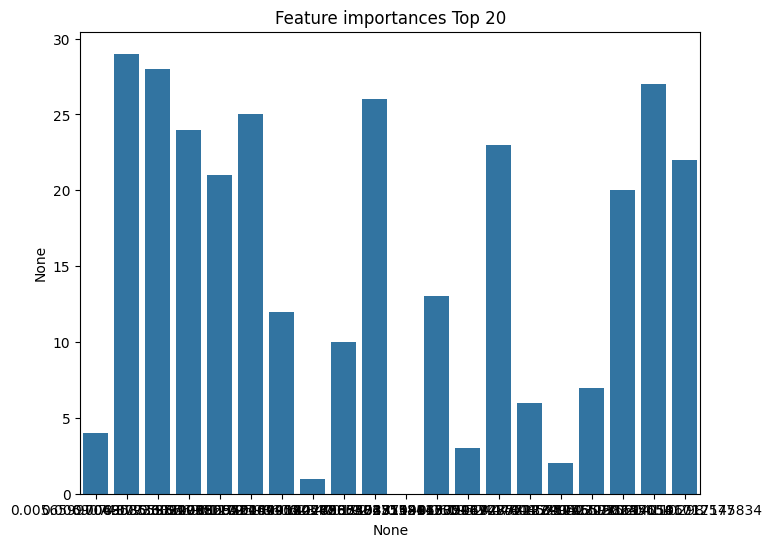

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ftr_importances_values=rf_clf1.feature_importances_
ftr_importances=pd.Series(ftr_importances_values)
ftr_top20=ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()

In [ ]:
!find /content -maxdepth 3 | sed -n '1,120p'

/content
/content/.config
/content/.config/default_configs.db
/content/.config/.last_survey_prompt.yaml
/content/.config/logs
/content/.config/logs/2026.04.02
/content/.config/.last_update_check.json
/content/.config/config_sentinel
/content/.config/active_config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/configurations
/content/.config/configurations/config_default
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/gce
/content/har.zip
/content/UCI HAR Dataset.names
/content/.ipynb_checkpoints
/content/UCI HAR Dataset.zip
/content/sample_data
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv


In [ ]:
!find /content -maxdepth 2 -name "*.zip"

/content/har.zip
/content/UCI HAR Dataset.zip


In [ ]:
!unzip "/content/UCI HAR Dataset.zip"

Archive:  /content/UCI HAR Dataset.zip
   creating: UCI HAR Dataset/
  inflating: UCI HAR Dataset/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/UCI HAR Dataset/
  inflating: __MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: __MACOSX/UCI HAR Dataset/._activity_labels.txt  
  inflating: UCI HAR Dataset/features.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features.txt  
  inflating: UCI HAR Dataset/features_info.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features_info.txt  
  inflating: UCI HAR Dataset/README.txt  
  inflating: __MACOSX/UCI HAR Dataset/._README.txt  
   creating: UCI HAR Dataset/test/
   creating: UCI HAR Dataset/test/Inertial Signals/
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt  
   creating: __MACOSX/UCI HAR Dataset/test/
   creating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_x_test.txt  
  inflating

In [ ]:
!find /content -maxdepth 3 | sed -n '1,120p'

/content
/content/.config
/content/.config/default_configs.db
/content/.config/.last_survey_prompt.yaml
/content/.config/logs
/content/.config/logs/2026.04.02
/content/.config/.last_update_check.json
/content/.config/config_sentinel
/content/.config/active_config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/configurations
/content/.config/configurations/config_default
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/gce
/content/har.zip
/content/__MACOSX
/content/__MACOSX/._UCI HAR Dataset
/content/__MACOSX/UCI HAR Dataset
/content/__MACOSX/UCI HAR Dataset/._activity_labels.txt
/content/__MACOSX/UCI HAR Dataset/._README.txt
/content/__MACOSX/UCI HAR Dataset/._.DS_Store
/content/__MACOSX/UCI HAR Dataset/._test
/content/__MACOSX/UCI HAR Dataset/._features.txt
/content/__MACOSX/UCI HAR Dataset/._features_info.txt
/content/__MACOSX/UCI HAR Dataset/test
/content/__MACOSX/UCI HAR Dataset/train
/content/__MACOSX/UCI HAR Dataset/._t

In [ ]:
import pandas as pd

# 예시 (파일 경로 맞게 수정해야 함)
X_train = pd.read_csv('/content/UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
X_test = pd.read_csv('/content/UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None)

y_train = pd.read_csv('/content/UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None)
y_test = pd.read_csv('/content/UCI HAR Dataset/test/y_test.txt', sep='\s+', header=None)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test=get_human_dataset()

# GBM 수행 시간 측정을 위함. 시작 시간 설정.
start_time=time.time()
gb_clf=GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred=gb_clf.predict(X_test)
gb_accuracy=accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print("GBM 수행 시간: {0:.1f} 초 ".format(time.time()-start_time))

GBM 정확도: 0.9379
GBM 수행 시간: 1630.1 초 


In [ ]:
pip install xgboost==1.7.6

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

In [ ]:
import xgboost
print(xgboost.__version__)

1.7.6


In [ ]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset=load_breast_cancer()
features=dataset.data
labels=dataset.target
cancer_df=pd.DataFrame(data=features, columns=dataset.feature_names)
cancer_df['target']=labels
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [ ]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [ ]:
# cancer_df에서 feature용 DataFrame과 Label용 Series 객체 추출
# 맨 마지막 칼럼이 Label임. Feature용 DataFrame은 cancer_df의 첫번째 칼럼에서 맨 마지막 두번째 칼럼까지를 :-1 슬라이싱으로 추출.
X_features=cancer_df.iloc[:,:-1]
y_label=cancer_df.iloc[:,-1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label, test_size=0.2,
                                                  random_state=156)


# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val=train_test_split(X_train, y_train, test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [ ]:
# 만약 구버전 XGBoost에서 DataFrame으로 DMatrix 생성이 안 될 경우 X_train.values로 넘파이 변환.
# 학습, 검증, 테스트용 DMatirix를 생성.
dtr=xgb.DMatrix(data=X_tr, label=y_tr)
dval=xgb.DMatrix(data=X_val, label=y_val)
dtest=xgb.DMatrix(data=X_test, label=y_test)

In [ ]:
params={'max_depth':3,
        'eta':0.05,
        'objective':'binary:logistic',
        'eval_metric':'logloss'
        }
num_rounds=400

In [ ]:
# 학습 데이터 셋은 'train' 또는 평가 데이터 셋은 'eval'로 명기합니다.
eval_list=[(dtr, 'train'),(dval, 'eval')] # 또는 eval_list=[(dval, 'eval')]만 명기해도 무방.

# 하이퍼 파라미터와 early_stopping 파라미터를 train() 함수의 파라미터로 전달
xgb_model=xgb.train(params=params, dtrain=dtr, num_boost_round=num_rounds, \
                    early_stopping_rounds=50, evals=eval_list)

[0]	train-logloss:0.65016	eval-logloss:0.66183
[1]	train-logloss:0.61131	eval-logloss:0.63609
[2]	train-logloss:0.57563	eval-logloss:0.61144
[3]	train-logloss:0.54310	eval-logloss:0.59204
[4]	train-logloss:0.51323	eval-logloss:0.57329
[5]	train-logloss:0.48447	eval-logloss:0.55037
[6]	train-logloss:0.45796	eval-logloss:0.52930
[7]	train-logloss:0.43436	eval-logloss:0.51534
[8]	train-logloss:0.41150	eval-logloss:0.49718
[9]	train-logloss:0.39027	eval-logloss:0.48154
[10]	train-logloss:0.37128	eval-logloss:0.46990
[11]	train-logloss:0.35254	eval-logloss:0.45474
[12]	train-logloss:0.33528	eval-logloss:0.44229
[13]	train-logloss:0.31892	eval-logloss:0.42961
[14]	train-logloss:0.30439	eval-logloss:0.42065
[15]	train-logloss:0.29000	eval-logloss:0.40958
[16]	train-logloss:0.27651	eval-logloss:0.39887
[17]	train-logloss:0.26389	eval-logloss:0.39050
[18]	train-logloss:0.25210	eval-logloss:0.38254
[19]	train-logloss:0.24123	eval-logloss:0.37393
[20]	train-logloss:0.23076	eval-logloss:0.36789
[2

In [ ]:
pred_probs=xgb_model.predict(dtest)
print('predict() 수행 결괏값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10],3))

# 예측 확률이 0.5보다 크면 1, 그렇지 않으면 0으로 예측값 결정하여 List 객체인 preds에 저장
preds=[1 if x>0.5 else 0 for x in pred_probs]
print('예측값 10개만 표시:', preds[:10])

predict() 수행 결괏값을 10개만 표시, 예측 확률 값으로 표시됨
[0.845 0.008 0.68  0.081 0.975 0.999 0.998 0.998 0.996 0.001]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [ ]:
def get_clf_eval(y_test, pred, pred_proba):
  confusion=confusion_matrix(y_test,pred)
  accuracy=accuracy_score(y_test, pred)
  precision=precision_score(y_test, pred)
  recall=recall_score(y_test,pred)
  f1=f1_score(y_test, pred)
  roc_auc=roc_auc_score(y_test,pred)
  print('오차행렬')
  print(confusion)
  print('정확도:{0:.4f},정밀도:{1:.4f},재현율:{2:.4f},F1:{3:.4f}, AUC:{4:.4f}'.format(accuracy,precision,recall,f1,roc_auc))
  get_clf_eval(y_test, preds, pred_probs)

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

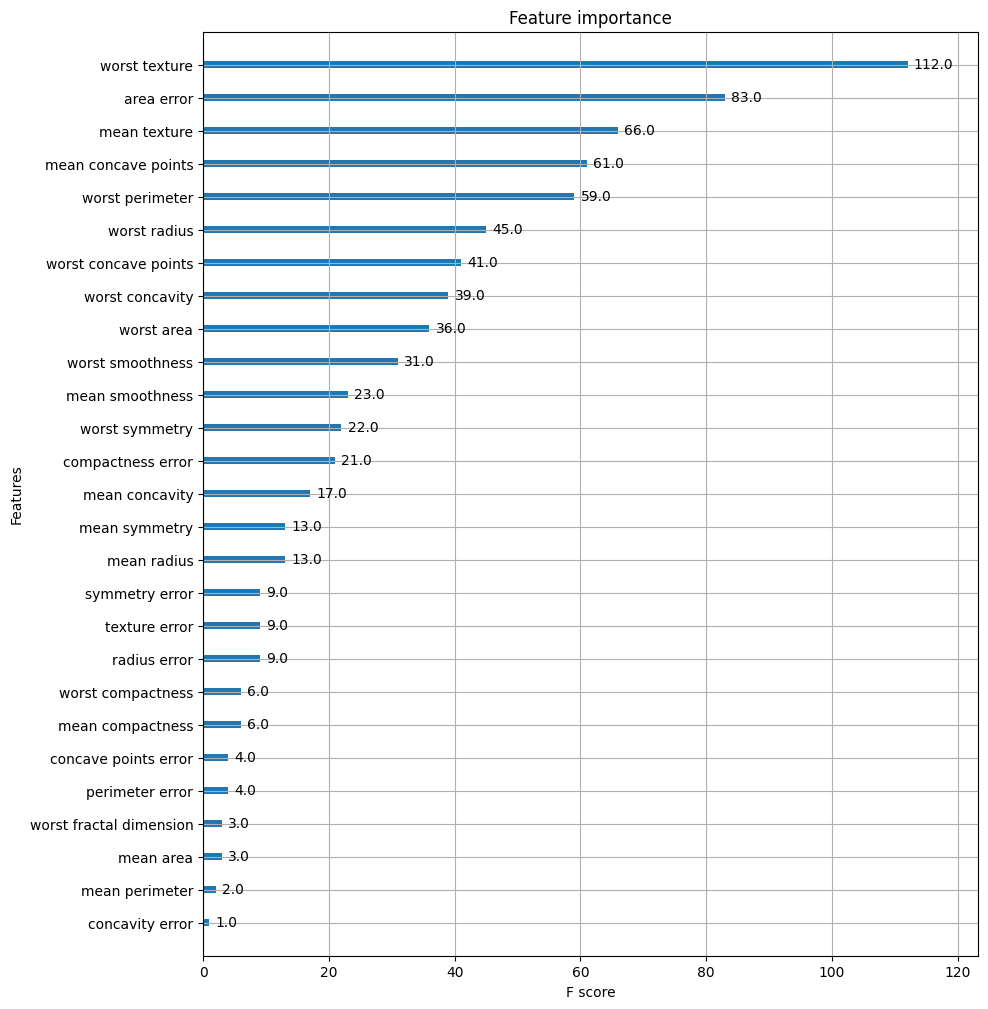

In [ ]:
from ast import increment_lineno
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax=plt.subplots(figsize=(10,12))
plot_importance(xgb_model, ax=ax)

In [ ]:
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

# Warning 메시지를 없애기 위해 eval_metric 값을 XGBClassifier 생성 인자로 입력.
xgb_wrapper=XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3,
                          eval_metric='logloss')
xgb_wrapper.fit(X_train, y_train, verbose=True)
w_preds=xgb_wrapper.predict(X_test)
w_pred_proba=xgb_wrapper.predict_proba(X_test)[:,1]


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

get_clf_eval(y_test, w_preds, w_pred_proba)

ValueError: Found input variables with inconsistent numbers of samples: [2947, 114]

In [ ]:
from xgboost import XGBClassifier

xgb_wrapper=XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3)
evals=[(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, early_stopping_rounds=50, eval_metric="logloss",
                eval_set=evals, verbose=True)

ws50_preds=xgb_wrapper.predict(X_test)
ws50_pred_proba=xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.65016	validation_1-logloss:0.66183
[1]	validation_0-logloss:0.61131	validation_1-logloss:0.63609
[2]	validation_0-logloss:0.57563	validation_1-logloss:0.61144
[3]	validation_0-logloss:0.54310	validation_1-logloss:0.59204
[4]	validation_0-logloss:0.51323	validation_1-logloss:0.57329
[5]	validation_0-logloss:0.48447	validation_1-logloss:0.55037
[6]	validation_0-logloss:0.45796	validation_1-logloss:0.52930
[7]	validation_0-logloss:0.43436	validation_1-logloss:0.51534
[8]	validation_0-logloss:0.41150	validation_1-logloss:0.49718
[9]	validation_0-logloss:0.39027	validation_1-logloss:0.48154
[10]	validation_0-logloss:0.37128	validation_1-logloss:0.46990
[11]	validation_0-logloss:0.35254	validation_1-logloss:0.45474
[12]	validation_0-logloss:0.33528	validation_1-logloss:0.44229
[13]	validation_0-logloss:0.31892	validation_1-logloss:0.42961
[14]	validation_0-logloss:0.30439	validation_1-logloss:0.42065
[15]	validation_0-logloss:0.29000	validation_1-logloss:0.40958
[1

In [ ]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.9740,F1:0.9677, AUC:0.9465
오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561,정밀도:0.9615,재현율:0.

RecursionError: maximum recursion depth exceeded

In [ ]:
xgb_wrapper.fit(X_tr,y_tr, eval_set=evals, verbose=True)
ws10_preds=xgb_wrapper.predict(X_test)
ws10_preds_proba=xgb_wrapper.predict_proba(X_test)[:,1]
get_clf_eval(y_test, ws10_preds, ws10_preds_proba)


# early_stopping_rounds를 10으로 설정하고 재학습.
xgb_wrapper.fit(X_tr, y_tr, early_stopping_rounds=10,
                eval_metric="logloss", eval_set=evals, verbose=True)

ws10_preds=xgb_wrapper.predict(X_test)
ws10_pred_proba=xgb_wrapper.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, ws10_preds, ws10_pred_proba)

[0]	validation_0-logloss:0.65016	validation_1-logloss:0.66183
[1]	validation_0-logloss:0.61131	validation_1-logloss:0.63609
[2]	validation_0-logloss:0.57563	validation_1-logloss:0.61144
[3]	validation_0-logloss:0.54310	validation_1-logloss:0.59204
[4]	validation_0-logloss:0.51323	validation_1-logloss:0.57329
[5]	validation_0-logloss:0.48447	validation_1-logloss:0.55037
[6]	validation_0-logloss:0.45796	validation_1-logloss:0.52930
[7]	validation_0-logloss:0.43436	validation_1-logloss:0.51534
[8]	validation_0-logloss:0.41150	validation_1-logloss:0.49718
[9]	validation_0-logloss:0.39027	validation_1-logloss:0.48154
[10]	validation_0-logloss:0.37128	validation_1-logloss:0.46990
[11]	validation_0-logloss:0.35254	validation_1-logloss:0.45474
[12]	validation_0-logloss:0.33528	validation_1-logloss:0.44229
[13]	validation_0-logloss:0.31892	validation_1-logloss:0.42961
[14]	validation_0-logloss:0.30439	validation_1-logloss:0.42065
[15]	validation_0-logloss:0.29000	validation_1-logloss:0.40958
[1

RecursionError: maximum recursion depth exceeded

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

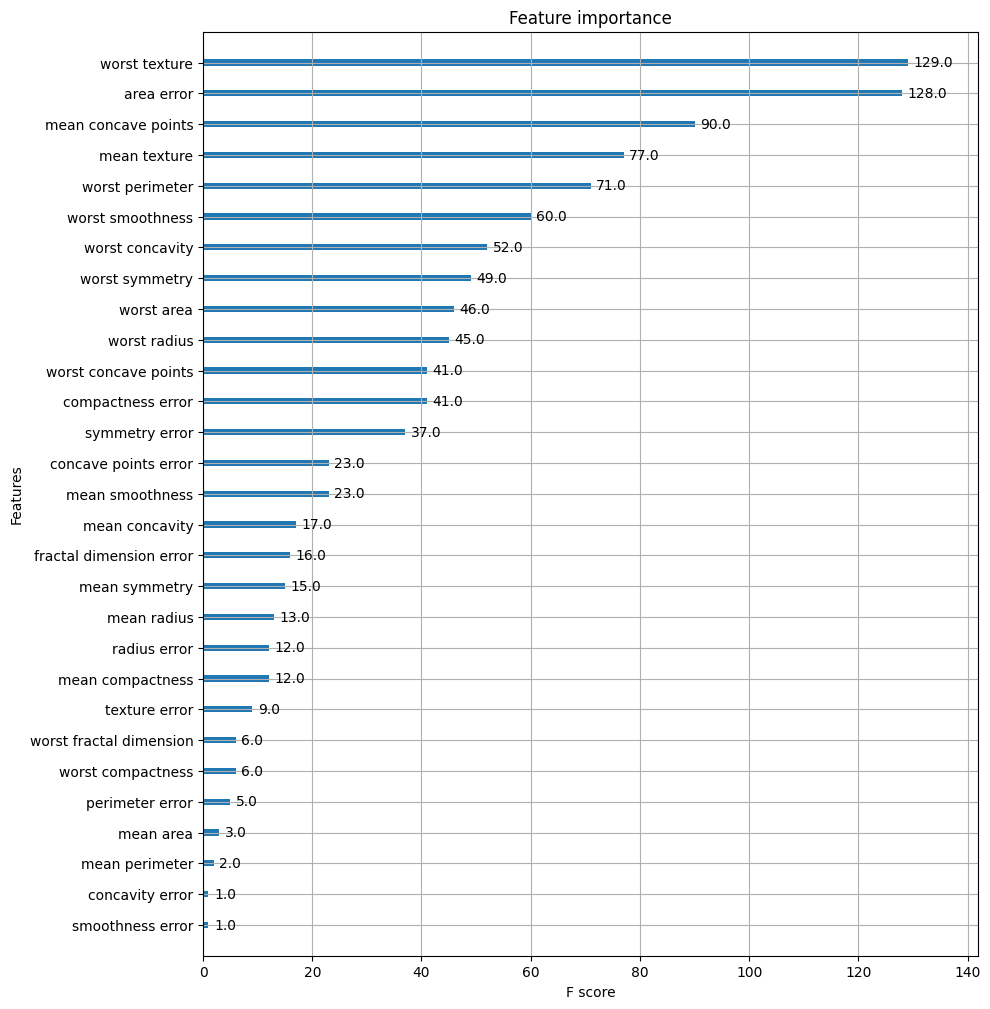

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax=plt.subplots(figsize=(10,12))
# 사이킷런 래퍼 클래스를 입력해도 무방.
plot_importance(xgb_wrapper, ax=ax)